Dataset downloaded and extracted!


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4457 - loss: 1.1776 - val_accuracy: 0.6432 - val_loss: 0.7115
Epoch 2/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7295 - loss: 0.5921 - val_accuracy: 0.6794 - val_loss: 0.6139
Epoch 3/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7455 - loss: 0.5275 - val_accuracy: 0.7023 - val_loss: 0.6134
Epoch 4/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7511 - loss: 0.5174 - val_accuracy: 0.6528 - val_loss: 0.6350
Epoch 5/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7509 - loss: 0.5015 - val_accuracy: 0.6864 - val_loss: 0.6099
Epoch 6/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7584 - loss: 0.4931 - val_accuracy: 0.6901 - val_loss: 0.6215
Epoch 7/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7567 - loss: 0.4978 - val_accuracy: 0.6486 - val_loss: 0.6640
Epoch 8/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7603 - loss: 0.4898 - val_accuracy: 0.

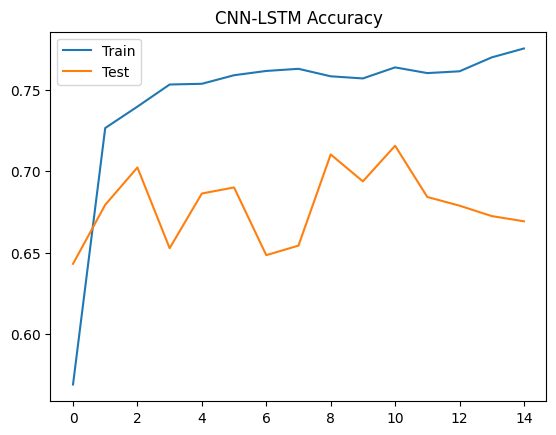

In [1]:
import numpy as np
import os
import urllib.request
import zipfile
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# ---------------- DOWNLOAD DATA ----------------
DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
ZIP_FILE = "UCI_HAR.zip"
DATA_DIR = "UCI HAR Dataset"

if not os.path.exists(DATA_DIR):
    print("Downloading dataset...")
    urllib.request.urlretrieve(DATA_URL, ZIP_FILE)
    with zipfile.ZipFile(ZIP_FILE, "r") as zip_ref:
        zip_ref.extractall(".")
    print("Dataset downloaded and extracted!")

# ---------------- LOAD DATA ----------------
def load_split(split="train"):
    path_x = os.path.join(DATA_DIR, split, f"X_{split}.txt")
    path_y = os.path.join(DATA_DIR, split, f"y_{split}.txt")
    X = np.loadtxt(path_x)
    y = np.loadtxt(path_y)
    return X, y

X_train, y_train = load_split("train")
X_test, y_test = load_split("test")

# ---------------- FILTER 4 ACTIVITIES ----------------
# 1=Walking, 2=Walking_Upstairs, 3=Walking_Downstairs, 4=Sitting
keep_classes = [1, 2, 3, 4]
train_mask = np.isin(y_train, keep_classes)
test_mask = np.isin(y_test, keep_classes)

X_train = X_train[train_mask]
y_train = y_train[train_mask]
X_test = X_test[test_mask]
y_test = y_test[test_mask]

# ---------------- PREPROCESS ----------------
# Take first 6 features (acceleration) for simplicity
X_train = X_train[:, :6]
X_test = X_test[:, :6]

# CNN-LSTM expects 3D input: (samples, timesteps, features)
# We'll treat each sample as 1 timestep (minimal working demo)
X_train = X_train.reshape(X_train.shape[0], 1, 6)
X_test = X_test.reshape(X_test.shape[0], 1, 6)

# Normalize
X_train = X_train / X_train.max()
X_test = X_test / X_test.max()

# Convert labels to 0-3
y_train = y_train - 1
y_test = y_test - 1
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# ---------------- MODEL ----------------
model = Sequential()
model.add(Conv1D(64, 1, activation='relu', input_shape=(1,6)))
model.add(MaxPooling1D(1))
model.add(Dropout(0.3))
model.add(LSTM(32))
model.add(Dense(16, activation='relu'))
model.add(Dense(4, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# ---------------- TRAIN ----------------
history = model.fit(X_train, y_train, epochs=15, batch_size=32, validation_data=(X_test, y_test))

# ---------------- EVALUATE ----------------
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

# ---------------- PLOT ----------------
plt.plot(history.history['accuracy'], label="Train")
plt.plot(history.history['val_accuracy'], label="Test")
plt.legend()
plt.title("CNN-LSTM Accuracy")
plt.show()
